In [6]:
# Step 1: Prepare the Data
import pandas as pd

# Create a DataFrame from the provided data
data = pd.read_csv("D:\ML project\DATASETS ML\predictive_maintenance.csv")




In [7]:
df=pd.DataFrame(data)

In [8]:
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [9]:
x=df[['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']]

In [10]:
y=df['Target']

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [13]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.svm import SVC

In [16]:
svm_model = SVC(kernel='linear')  # You can try different kernels: 'linear', 'rbf', etc.
svm_model.fit(x_train, y_train)


SVC(kernel='linear')

In [17]:
y_pred = svm_model.predict(x_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report

In [24]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Classification Report:\n{report}')

Accuracy: 0.9695
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1939
           1       0.00      0.00      0.00        61

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.94      0.97      0.95      2000



C:\Users\Student\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Student\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Student\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


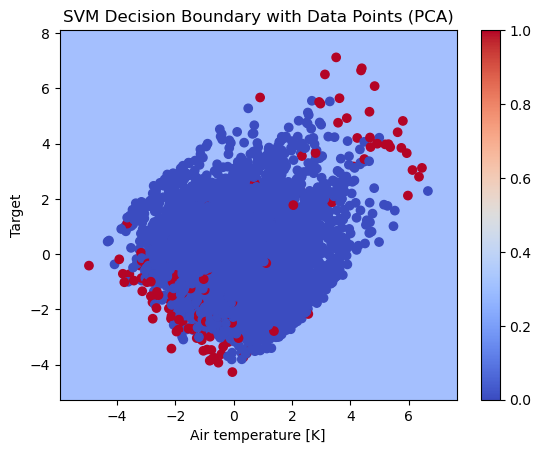

Vehicles requiring maintenance (indices): []


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


x=scaler.fit_transform(x)
# Use PCA for dimensionality reduction to 2D
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# Generate a grid of points to plot the decision boundary
h = .02  # step size in the mesh
x_min, x_max = x_pca[:, 0].min() - 1, x_pca[:, 0].max() + 1
y_min, y_max = x_pca[:, 1].min() - 1, x_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict the labels for each point in the meshgrid
Z = svm_model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y, cmap=plt.cm.coolwarm)

# Labeling the axes
plt.xlabel('Air temperature [K]')
plt.ylabel('Target')

# Add a legend
plt.colorbar()

# Add titles and show the plot
plt.title('SVM Decision Boundary with Data Points (PCA)')
plt.show()



In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("D:\ML project\DATASETS ML\predictive_maintenance.csv")

# Preprocess the dataset
df['UDI'], _ = pd.factorize(df['UDI'])
df['Product ID'], _ = pd.factorize(df['Product ID'])
df['Type'], _ = pd.factorize(df['Type'])
df['Air temperature [K]'], _ = pd.factorize(df['Air temperature [K]'])
df['Process temperature [K]'], _ = pd.factorize(df['Process temperature [K]'])
df['Rotational speed [rpm]'], _ = pd.factorize(df['Rotational speed [rpm]'])
df['Torque [Nm]'], _ = pd.factorize(df['Torque [Nm]'])
df['Tool wear [min]'], _ = pd.factorize(df['Tool wear [min]'])
df['Target'], _ = pd.factorize(df['Target'])
df['Failure Type'], _ = pd.factorize(df['Failure Type'])

# Define features and target
X = df.drop(columns=['Target'])
y = df['Target']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=123)

# Create and fit the SVM model
svm_model = SVC(kernel='linear', random_state=123)
svm_model.fit(X_train, y_train)

# Predict on the test set
y_pred = svm_model.predict(X_test)

# Create a DataFrame with the results
results = pd.DataFrame({
    'Vehicle_ID': X_test[:, 0],  # Assuming the first column corresponds to the vehicle ID after scaling
    'Actual': y_test,
    'SVM_Prediction': y_pred
})

# Define a function to decide if a vehicle needs maintenance based on the prediction
def needs_maintenance(prediction):
    # Simple rule: Assume prediction 0 means no maintenance, prediction 1 means maintenance
    return 1 if prediction == 1 else 0

results['Service_Needed'] = results['SVM_Prediction'].apply(needs_maintenance)

# Print the results with the maintenance decision
# print("First few rows of the result:\n", results.head())

# # Print detailed maintenance decision for each vehicle
# print("\nVehicles that need service:")
# for index, row in results.iterrows():
#     if row['Service_Needed'] == 1:
#         print(f"Vehicle ID {row['Vehicle_ID']} needs service")

# print("\nVehicles that do not need service:")
# for index, row in results.iterrows():
#     if row['Service_Needed'] == 0:
#         print(f"Vehicle ID {row['Vehicle_ID']} does not need service")
print(results.head())  # Print only the first few rows for brevity

# Print detailed maintenance decision for each vehicle
for index, row in results.iterrows():
    service_needed = 'needs service' if row['Service_Needed'] == 1 else 'does not need service'
    print(f"Vehicle ID {row['Vehicle_ID']} {service_needed}")
# Calculate and print the evaluation metrics
print("\nMaintenance Prediction Accuracy: ", accuracy_score(y_test, results['Service_Needed']))
print("F1 Score: ", f1_score(y_test, results['Service_Needed']))
print("Confusion Matrix: \n", confusion_matrix(y_test, results['Service_Needed']))
print("ROC AUC Score: ", roc_auc_score(y_test, results['Service_Needed']))


      Vehicle_ID  Actual  SVM_Prediction  Service_Needed
2656   -0.811812       0               0               0
445    -1.577725       0               0               0
9505    1.560751       0               0               0
332    -1.616869       0               0               0
4168   -0.288040       0               0               0
Vehicle ID -0.8118122175665939 does not need service
Vehicle ID -1.5777250885031158 does not need service
Vehicle ID 1.5607509905040704 does not need service
Vehicle ID -1.6168694369498942 does not need service
Vehicle ID -0.28804005073890454 does not need service
Vehicle ID -0.9129639852343752 does not need service
Vehicle ID 0.38018515416229437 does not need service
Vehicle ID -1.7294527400047877 does not need service
Vehicle ID 0.9534939743341369 does not need service
Vehicle ID -0.18931315421384406 does not need service
Vehicle ID -0.08885420687255445 does not need service
Vehicle ID 0.430761037996185 does not need service
Vehicle ID -0.648999440